In [1]:
# Basic Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modeling

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor , RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso ,Ridge , ElasticNet
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
# Importing Data 
df1 = pd.read_csv("C:/Users/abhis/project/ML_project_with_MLFlow/mlproject/notebooks/data/Flipkart_mobile_brands_scraped_data.csv")
df2 = pd.read_csv("C:/Users/abhis/project/ML_project_with_MLFlow/mlproject/notebooks/data/Flipkart_Mobiles.csv")

df = pd.concat([df1,df2], ignore_index=True)
print("Shape of the DataFrame :", df.shape)

Shape of the DataFrame : (5761, 8)


In [3]:
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990.0,17990.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990.0,17990.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990.0,15990.0


In [4]:
df.dtypes

Brand              object
Model              object
Color              object
Memory             object
Storage            object
Rating            float64
Selling Price     float64
Original Price    float64
dtype: object

### Data Cleaning

In [5]:
# Converting Object Dtypes to string
features = ['Memory','Storage']
for i  in features :
    df[i] = df[i].convert_dtypes()
    df[i] = df[i].astype(str).str.lower().str.split()

In [6]:
import re

def clean_feature_column(df, column_name):
    """
    Uses Regex to extract numbers and units, handling MB to GB conversion.
    """
    def extract_and_convert(val):
        val = str(val).lower().strip()
        
        # Regex breakdown:
        # (\d+\.?\d*) -> Finds digits, including decimals (e.g., 4 or 4.5)
        # \s* -> Handles zero or more spaces
        # (gb|mb)     -> Finds the unit
        match = re.search(r"(\d+\.?\d*)\s*(gb|mb)", val)
        
        if match:
            number = float(match.group(1)) # The numeric part
            unit = match.group(2)          # The unit part
            
            if unit == 'mb':
                return number / 1024
            return number # It's already GB
        
        # If no unit found, try to just find a number
        only_number = re.search(r"(\d+\.?\d*)", val)
        if only_number:
            return float(only_number.group(1))
            
        return 0.0

    return df[column_name].apply(extract_and_convert)

# --- Implementation ---
# Works for: "4 GB", "4GB", "['4', 'GB']", "Memory: 512MB"
df['Memory_Cleaned'] = clean_feature_column(df, 'Memory')
df['Storage_Cleaned'] = clean_feature_column(df, 'Storage')


In [7]:
df["Memory_Cleaned"]

0       4.0
1       4.0
2       6.0
3       6.0
4       4.0
       ... 
5756    6.0
5757    6.0
5758    8.0
5759    8.0
5760    8.0
Name: Memory_Cleaned, Length: 5761, dtype: float64

In [8]:
df['Memory_Cleaned'].unique()

array([4.00e+00, 6.00e+00, 3.00e+00, 8.00e+00, 2.00e+00, 1.20e+01,
       1.00e+00, 5.12e+02, 1.50e+00, 7.68e+02, 1.60e+01, 1.80e+01,
       6.40e+01, 3.20e+01, 1.28e+02, 0.00e+00, 2.56e+02, 1.53e+02,
       1.00e+01, 4.60e+01, 5.00e-01, 1.00e+02, 3.00e+01, 7.17e+02])

In [9]:
df['Storage_Cleaned'].unique()

array([ 64.  , 128.  ,  32.  , 256.  ,  16.  ,   8.  ,   4.  , 512.  ,
         0.  ,  48.  ,  10.  , 140.  ,   1.  ,   2.27,   2.  , 153.  ,
         2.3 , 100.  ,  65.  , 129.  , 130.  ])

In [10]:
def filter_range(df, column, min_limit, max_limit):
    """
    Keeps only the values within [min_limit, max_limit].
    Everything else is set to NaN.
    """
    # Ensure the column is numeric (handles scientific notation like 4.00e+00)
    df[column] = pd.to_numeric(df[column], errors='coerce')
    
    # Apply range filtering
    df[column] = df[column].where(df[column].between(min_limit, max_limit), np.nan)
    
    return df

# --- Usage ---

# For Storage: Keeping values between 4GB and 2048GB
df = filter_range(df, 'Storage_Cleaned', 4, 2048)

# For Memory (RAM): Keeping values between 0.5GB and 64GB
df = filter_range(df, 'Memory_Cleaned', 0.5, 64)

# Drop the non-authentic rows entirely
df_cleaned = df.dropna(subset=['Storage_Cleaned', 'Memory_Cleaned'])

In [11]:
raw_colors = [
    'Moonlight Black', 'Mint Cream', 'Electric Black', 'Deep Blue', 'Black', 'Blue', 'Flowing Silver', 'Crystal Blue', 
    'Ink Black', 'Lake Green', 'Mystery Black', 'Fantastic Purple', 'Matte Black', 'Moonlight Gold', 'Aurora', 
    'Stellar Black', 'Magic Blue', 'Starry Blue', 'Crystal Black', 'Metallic White', 'Fantasy White', 'Navy Blue', 
    'Fancy Blue', 'Pearl Blue', 'Astral Blue', 'CRYSTAL BLACK', 'Dynamic Black', 'Dynamic Orange', 'Mystery Blue', 
    'Fairy White', 'Fluid Black', 'Sky White', 'Midnight Black', 'Rainbow Silver', 'Auroral Blue', 'Crystal Silver', 
    'Space Silver', 'Fancy White', 'Midnight Blue', 'Glaring Gold', 'Starry Black', 'Red', 'JET BLACK', 'Luminous Black', 
    'Unicorn White', 'Prism Black', 'Piano Black', 'Classic Silver', 'Lightening Black', 'Marine Green', 'Bordeaux Red', 
    'Galactic Blue', 'Marble Green', 'Diamond Blue', 'Silky White', 'Starry Night', 'Space Purple', 'Dazzling White', 
    'Rose Gold', 'Gold', 'Blazing Blue', 'Purple', 'Champagne', 'Aurora Blue', 'Mist Black', 'Twilight Black', 
    'Stream White', 'Vanilla Mint', 'Green', 'Grey', 'Sunrise Red', 'Twilight Blue', 'Starry Purple', 'Glowing Gold', 
    'Glowing Black', 'Diamond Red', 'Glaze Blue', 'Mirror Black', 'Jade Black', 'White', 'Stellar Purple', 
    'Fluorite Purple', 'Waterfall Grey', 'Aurora Green', 'Thunder Black', 'Fancy white', 'Jewelry White', 'Silver', 
    'Glacier Blue', 'Neon Purple', 'Space Blue', 'Jet Black', 'Majestic Gold', 'Ocean Green', 'Ocean Blue', 
    'Starry purple', 'Amazing Silver', 'Blue MB', 'Quantum Silver', 'Tornado Black', ' Tornado Black', 'Just Black', 
    'Clearly White', 'Not Pink', 'Very Silver', 'Quite Black', 'Aurora Silver', 'Gray', 'midnight blue', 'Midnight Purple', 
    'Moroccan Blue', 'Smokey Gray', 'Black Blue', 'MAGIC BLUE', 'Thunder Blue', 'Thunder blue', 'Platinum', 'Titan', 
    'Silver Titan', 'Platinum Grey', 'Brown', 'Ice', 'Black Titan', 'AURORA SILVER', 'Aurora Gray', 'Laser Blue', 
    'Black & Blue', 'Black Gold', 'Gold & Black', 'Illusion Sky', 'Carbon', 'Genuine Leather Black', 'Titan Silver', 
    'Pink', 'Metallic Gray', 'Lavender Violet', 'Genuine Leather Brown', 'Meteor Silver', 'Silver Blue', 'Yellow', 
    'Rose Pink', 'Titanium', 'Aqua Blue', 'Orange', 'Cool Blue', 'Cool Grey', 'Racing Blue', 'Racing Silver', 'Cross Black', 
    'Cross Blue', 'Space Black', 'Watery Grey', 'Watery Blue', 'Universe Blue', 'Metal Grey', 'Universe Purple', 
    'Laser Black', 'Supersonic Black', 'Supersonic Blue', 'Infinite Black', 'Power Blue', 'Infinite Blue', 'Cyber Silver', 
    'Cyber Black', 'Power Silver', 'Rich Grey', 'Rich Green', 'Mist Blue', 'Nebula', 'Sword Black', 'Blade Silver', 
    'Frozen Blue', 'Chroma White', 'Fusion Green', 'Diamond Black', 'Arctic White', 'Cosmos Black', 'Eclipse Black', 
    'Comet White', 'Lunar White', 'Pearl White', 'Moonlight Silver', 'Mint Green', 'Carbon Black', 'Oxygen Blue', 
    'Oxygen Green', 'Pearl Green', 'Illuminating Yellow', 'Sparkling Blue', 'Rust Red', 'Dashing Blue', 'Moss Green', 
    'Crystal Green', 'Racing Yellow', 'Comet Blue', 'Mystic Black', 'Volcano Grey', 'Blazing Red', 'Fusion Blue', 
    'Mist White', 'Sun Kissed Leather', 'Black Ninja', 'White Knight', 'Glory Silver', 'Victory Blue', 'So White', 
    'That Green', 'That White', 'Lightning Red', 'So Blue', 'That Blue', 'Ambitious Black', 'Fiery Gold', 'Brave Blue', 
    'Lightning Blue', 'Solar Red', 'Diamond Sapphire', 'Diamond Ruby', 'Forest Green', 'Lightning Orange', 'Radiant Blue', 
    'Red Brick', 'Concrete', 'Garlic', 'Onion', 'Polar White', 'Neptune Blue', 'Super Polar White', 'Royal Blue', 
    'Dark Blue', 'Oxford Blue', 'Rainbow Black', np.nan, 'Mocha Gold', 'GOLDEN', 'Black and Gold', 'Latte Gold', 
    'Champagne Gold', 'Polar Gold', 'CHAMPAGNE GOLD', 'Fjord', 'Glacier', 'Polar Night', 'Charcoal Grey', 'Nordic Blue', 
    'Night | Dark Blue', 'Dusk | Purple', 'Sand', 'Dusk', 'Charcoal', 'Fjord Blue', 'Dusk Purple', 'Night', 'Copper', 
    'Blue&Copper', 'Grey / Silver', 'Warm Red', 'Copper/Black', 'Blue & Silver', 'Blue/Copper', 'Silver White', 
    'Black&Blue', 'Cyan Green', 'Baltic', 'Iron', 'Steel', 'Pewter / White', 'Tempered Blue', 'SAND', 'CYAN', 'Dark Grey', 
    'CHARCOAL', 'Bright Green', 'White & Copper', 'Pink Sand', 'Polished Copper', 'Copper White', 'Polished Blue', 
    'Bright Red', 'Black & Copper', 'Sierra Blue', 'Starlight', 'Midnight', 'Coral', 'Pacific Blue', 'Midnight Green', 
    'Graphite', 'Space Grey', 'Space Gray', 'Denim Blue', 'Denim Black', 'Sky Blue', 'Sea Green', 'Mirage Blue', 
    'Celestial Black', 'Mint', 'Arctic blue', 'Mirage Black', 'Sky blue', 'Cream', 'Awesome Black', 'Light Blue', 
    'Prism Crush Blue', 'Phantom Black', 'Laser Grey', 'Awesome White', 'Arctic Blue', 'Slate Black', 'Laser Green', 
    'Awesome Blue', 'Cloud Navy', 'Prism White', 'Violet', 'Awesome Violet', 'Mystic Bronze', 'Aura Black', 
    'Haze Crush Silver', 'Prism Crush Red', 'Iceberg blue', 'Metallic Blue', 'Prism Crush Violet', 'Diamond White', 
    'Mystic Blue', 'Prism Crush Black', 'Mystic Green', 'Cloud White', 'Prism Crush White', 'Gradation Blue', 
    'Prism Dot Black', 'Caviar Black', 'Cosmic Gray', 'Seawater Blue', 'Absolute black', 'Ceramic Black', 'Ceramic White', 
    'White Pearl', 'Black Sapphire', 'Gold Sand', 'Electric Blue', 'Angel Gold', 'Fusion Black', 'Shimmery White', 
    'Phantom Gray', 'Aura Glow', 'Prism Dot Gray', 'Cloud Blue', 'Dark Gray', 'Iris Charcoal', 'Phantom Violet', 
    'Iceberg Blue', 'Stainless Black', 'Lemonade Blue', 'black sapphire', 'Metallic Copper', 'White Frost', 'IceBerg Blue', 
    'Charcoal Black', 'Lavender Purple', 'Prism Crush Silver', 'Prism Blue', 'Burgundy Red', 'Ghost White', 'Cloud Pink', 
    'Coral Blue', 'Frosted Gold', 'Aura Red', 'Phantom White', 'Orchid Grey', 'Black Sky', 'Pearl white', 'Lilac Purple', 
    'Silver Titanium', 'Deep Black', 'Classic White', 'Gold Platinum', 'Polaris Blue', 'Copper Gold', 'Sunrise Gold', 
    'Alpine White', 'Chic White', 'Blue Coral', 'Aura White', 'Quartz Green', 'Phantom Silver', 'Pebble Blue', 'Black Onyx', 
    'Cloud Mint', 'Wine Red', 'Cloud Lavender', 'Cloud Red', 'Raven Black', 'Gradation Black', 'Cosmic Black', 'Noble Black', 
    'Frost White', 'Maple Gold', 'Marble White', 'Bronze Gold', 'Charcoal Gray', 'Blossom Pink', 'COCKTAIL ORANGE', 
    'Titan Gray', 'Metallic Silver', 'Pure White', 'Black Pearl', 'Pink Gold', 'Fine Gold', 'Venom Black', 'Grey/Dark Grey', 
    'Grey / Dark Grey', 'dark gold', 'Golden', 'Black/Tuxedo Black', 'Starry Night Black', 'Sprite', 'GREY / GRAPHITE GREY', 
    'Grey/Graphite Grey', 'Graphite Grey', 'GREY/BLACK', 'Tahiti Blue', 'Cyber Teal', 'Aurora Grey', 'Frosted Champagne', 
    'Dynamic Gray', 'Coral Red', 'Electric Graphite', 'Breeze Blue', 'Frosted Emerald', 'Super Black', 'Polished Graphite', 
    'Grey/Flash Gray', 'Frosted Pearl', 'Indigo Black', 'Sapphire Gradient', 'Dark Pearl', 'Volcanic Grey', 'Electric Violet', 
    'Pastel Sky', 'Moonlight White', 'Sapphire Blue', 'Misty Blue', 'Frosted Silver', 'Smoky Sangria', 'Ultra Violet', 
    'Lunar Gray', 'Sterling Blue', 'Rich Cranberry', 'Cosmic Blue', 'Bronze Gradient', '100 MB', 'Crystal Pink', 
    'Twilight Orange', 'Caribbean Blue', 'Metallic Sage', 'Lunar Grey', 'Black Leather', 'Graphite Black', 'Steel Blue', 
    'Power Black', 'Greyish Black', 'Mostly Blue', 'Lime Green', 'Obsidian Black', 'Purist Blue', 'Nebula Blue', 
    'Midday Dream', 'Diamond Glow', 'Dawn White', 'Roman Black', 'Diamond Flare', 'Olive Black', 'Titanium Sapphire', 
    'Slate Gray', 'Prism Magic', 'Crystal Symphony', 'Sunset Jazz', 'Gravity Black', 'Agate Red', 'Deep Sea Blue', 
    'Sunset Melody', 'Sunset Dazzle', 'Dusk Blue', 'Fantastic Rainbow', 'Emerald Black', 'Aquamarine Green', 'Midnight Jazz', 
    'Shimmer Blue', 'Coral Green', 'Twilight Grey', 'Atlantic Blue', 'Pacific Sunrise', 'Lunar Silver', 'Jazz Blue', 
    'Tuscany Coral', 'Vinyl Black', 'Celestial Silver', 'LUNAR WHITE', 'CELESTIAL SILVER', 'COSMIC BLACK', 'Kind of Grey', 
    'More Than White', 'Not just Blue', 'Metallic Grey', 'Lake Blue', 'Matte Gold', 'Onyx Black', 'Ruby Red', 'Sunset Red', 
    'Midnight Grey', 'Sea Blue', 'Sporty Orange', 'Electric Green', 'Fiery Red', 'Mighty Black', 'Sunrise Flare', 
    'Nature Green', 'SeaBlue', 'Flame Red', 'Dark Nebula', 'Dark Night', 'Cosmic Purple', 'MOONLIGHT WHITE', 'Nebula Red', 
    'Astro Moonlight White', 'Aqua Green', 'Pebble Grey', 'Shadow Black', 'Glacier White', 'Interstellar Black', 'Bold Red', 
    'Elegant Blue', 'Prime Black', 'Brilliant Black', 'Sprinkle White', 'Carbon Grey', 'Topaz Gold', 'Sunset Blue', 
    'White Birch', 'Blue Lagoon', 'Milkyway Grey', 'Meteor Grey', 'Gold Sepia', 'Gold and Silver', 'Fervor Red', 
    'Santorini White', 'Saffron Grey', 'Glossy Black', 'Amber Gold', 'White  ', 'Gunmetal Grey', 'Grey ', 'Rainbow Blue', 
    'Predator Black', 'Gunmetal Silver', 'Armoured Edition', 'Two shades of black', 'Green and Greener', 'Out of Blue', 
    'Slate Blue', 'Pitch Black', 'Brick Red', 'Matrix Purple', 'Pheonix Red', 'Rosso Red', 'Daybreak Blue', 'Neo Blue', 
    'Neo Black', 'Luna White ', 'Voyager Grey', 'Mercury Silver', 'Asteroid Black', 'Awesome Mint', 'Phantom Green', 
    'Lavender  ', 'Matte Aqua', 'Sunshine Gold', 'Stardust Black', 'Neon Spark', 'Enigma Black', 'Aurora Dawn', 'Alpha Grey', 
    'Frost Blue', 'Skyline Blue', 'Phantom Purple', 'Sonic Blue', 'Sonic Black', 'Nebula Purple', 'Dazzling Gold', 
    'Pearl Black', 'Energetic Blue', 'Celestial Magic', 'Meteorite Black', 'Stealth Black', 'Purple Mist', 'Pacific Pearl', 
    'Camo Green', 'Aquamarine Blue', 'Stardust White', 'Diamond Dazzle', 'Aegean Blue', 'Purple  ', 'Morandi Green', 
    'Polar Black', 'Green Wave', 'Silver Wave', 'Emerald Green', 'Quetzal Cyan', 'Ocean Wave', 'Celestial Snow', 
    'Symphony Cyan', 'Haze Green', 'Glacier Green', 'Mithril Grey', 'Nordic Secret', 'Milan Black', 'Sandstone Black', 
    'Ice Blue', 'Sapphire Cyan', 'Bordeaux Red ', 'Heart of Ocean', 'Silver Diamond', 'Topaz Blue', 'Moonlight Jade', 
    'Amber Red', 'Aether Black', 'Tradew Grey', 'Mocha Brown', 'City Blue', 'Serene Gold', 'Blush Gold', 'Magic Gold', 
    'Shark Grey', 'Quartz Black', 'Charcoal Blue', 'Black Diamond', 'Berlin Gray', 'Twilight Purple', 'Bolivia Blue', 
    'Bronze Gold Black', 'Startrails Blue', 'Shadow Grey', 'Rainbow Fantasy', 'Starlight Black', 'Royal Gold', 'Storm White', 
    'Alpine Green', 'Glowing Galaxy', 'Meteor Black', 'Stargaze White', 'Sunrise Blue ', 'Azure Glow', 'Starry Glow', 
    'Glowing Green', 'Blazing Black', 'Icy Blue'
]

In [12]:
def simplify_smartphone_color(color):
    # Handle missing or null values safely
    if pd.isna(color) or str(color).strip().lower() in ['nan', '', 'none']:
        return np.nan
        
    # Standardize string formatting
    c = str(color).lower().strip()
    
    # 1. Handle explicit multi-tone / dual colors first 
    # (Captures standard separators like &, /, and 'and', plus pipe symbols like 'night | dark blue')
    if '&' in c or '/' in c or '|' in c or ' and ' in c:
        if 'black' in c and 'gold' in c: return 'Black & Gold'
        if 'black' in c and 'blue' in c: return 'Black & Blue'
        if 'blue' in c and 'silver' in c: return 'Blue & Silver'
        if 'black' in c and 'copper' in c: return 'Black & Copper'
        if 'white' in c and 'copper' in c: return 'White & Copper'
        if 'grey' in c or 'gray' in c: return 'Grey'
    
    # 2. Map industry-standard brand synonyms and specific weird ones to simple colors
    synonyms = {
        'graphite': 'Black/Grey',
        'charcoal': 'Grey',
        'carbon': 'Black',
        'starlight': 'Silver/White',
        'midnight': 'Black',
        'cream': 'White/Cream',
        'gold': 'Gold',
        'golden': 'Gold',
        'champagne': 'Gold',
        'platinum': 'Silver',
        'titan': 'Grey',
        'titanium': 'Grey',
        'copper': 'Copper/Bronze',
        'bronze': 'Copper/Bronze',
        'sand': 'Gold/Beige',
        'concrete': 'Grey',
        'garlic': 'White',
        'onion': 'Purple/Pink', # A wild guess for 'onion' based on red onions
        'steel': 'Silver/Grey',
        'iron': 'Grey',
        'pewter': 'Silver/Grey'
    }
    
    for key, val in synonyms.items():
        if key in c:
            return val

    # 3. Base keyword matching (Ordered by typical priority)
    if 'black' in c:  return 'Black'
    if 'blue' in c:   return 'Blue'
    if 'white' in c:  return 'White'
    if 'silver' in c: return 'Silver'
    if 'grey' in c or 'gray' in c: return 'Grey'
    if 'purple' in c or 'violet' in c or 'lilac' in c or 'lavender' in c: return 'Purple'
    if 'green' in c or 'mint' in c or 'emerald' in c: return 'Green'
    if 'red' in c or 'ruby' in c or 'bordeaux' in c or 'coral' in c: return 'Red'
    if 'pink' in c:   return 'Pink'
    if 'orange' in c: return 'Orange'
    if 'yellow' in c: return 'Yellow'
    if 'cyan' in c or 'teal' in c or 'aqua' in c: return 'Cyan/Teal'
    if 'brown' in c or 'leather' in c or 'mocha' in c: return 'Brown'
    
    # 4. If it's a rare color or unmapped marketing name, capitalize it nicely and keep it
    return str(color).strip().title()

# Apply the clean function
df_cleaned['cleaned_color'] = df_cleaned['Color'].apply(simplify_smartphone_color)

C:\Users\abhis\AppData\Local\Temp\ipykernel_28872\743430236.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['cleaned_color'] = df_cleaned['Color'].apply(simplify_smartphone_color)


In [13]:
df_cleaned = df_cleaned.drop(columns=["Memory","Storage","Color"])

In [17]:
df_cleaned.shape

(5408, 8)

In [18]:
df_cleaned.rename(columns={"Memory_Cleaned":"Memory", "Storage_Cleaned":"Storage" ,"cleaned_color":"Color"}, inplace=True)

In [21]:
print("categories in 'Brand' variable :" , end=" ")
print(df_cleaned["Brand"].unique())

print("categories in 'color' variable :" , end=" ")
print(df_cleaned["Color"].unique())

print("categories in 'Memory' variable :" , end=" ")
print(df_cleaned["Memory"].unique())

print("categories in 'Model' variable :" , end=" ")
print(df_cleaned["Model"].unique())

print("categories in 'Rating' variable :" , end=" ")
print(df_cleaned["Rating"].unique())

print("categories in 'Original Price' variable :" , end=" ")
print(df_cleaned["Original Price"].unique())

print("categories in 'Storage' variable :" , end=" ")
print(df_cleaned["Storage"].unique())

categories in 'Brand' variable : ['OPPO' 'HTC' 'IQOO' 'Google Pixel' 'LG' 'ASUS' 'realme' 'GIONEE' 'Nokia'
 'Apple' 'SAMSUNG' 'Lenovo' 'Motorola' 'POCO' 'vivo' 'Xiaomi' 'Infinix']
categories in 'color' variable : ['Black' 'White/Cream' 'Blue' 'Silver' 'Green' 'Purple' 'Gold' 'Aurora'
 'White' 'Orange' 'Red' 'Starry Night' 'Grey' 'Pink' 'Brown' 'Ice'
 'Black & Blue' 'Black & Gold' 'Illusion Sky' 'Yellow' 'Nebula'
 'Diamond Sapphire' 'Purple/Pink' nan 'Fjord' 'Glacier' 'Polar Night'
 'Gold/Beige' 'Dusk' 'Night' 'Copper/Bronze' 'Black & Copper'
 'Blue & Silver' 'Baltic' 'Silver/Grey' 'Cyan/Teal' 'White & Copper'
 'Silver/White' 'Black/Grey' 'Cloud Navy' 'Aura Glow' 'Sprite'
 'Frosted Pearl' 'Sapphire Gradient' 'Dark Pearl' 'Pastel Sky'
 'Smoky Sangria' 'Rich Cranberry' 'Metallic Sage' 'Midday Dream'
 'Diamond Glow' 'Diamond Flare' 'Prism Magic' 'Crystal Symphony'
 'Sunset Jazz' 'Sunset Melody' 'Sunset Dazzle' 'Fantastic Rainbow'
 'Pacific Sunrise' 'Sunrise Flare' 'Dark Nebula' 'Dark Night

### Preparing X and Y variables

In [22]:
x = df_cleaned.drop(columns=["Selling Price"], axis=1)
x

,Brand,Model,Rating,Original Price,Memory,Storage,Color
0,OPPO,A53,4.5,15990.0,4.0,64.0,Black
1,OPPO,A53,4.5,15990.0,4.0,64.0,White/Cream
2,OPPO,A53,4.3,17990.0,6.0,128.0,Black
3,OPPO,A53,4.3,17990.0,6.0,128.0,White/Cream
4,OPPO,A53,4.5,15990.0,4.0,64.0,Black
...,...,...,...,...,...,...,...
5756,SAMSUNG,M52 5G,4.3,25990.0,6.0,128.0,Black
5757,SAMSUNG,M52 5G,4.3,28449.0,6.0,128.0,Blue
5758,SAMSUNG,M52 5G,4.3,31489.0,8.0,128.0,Blue
5759,SAMSUNG,M52 5G,4.2,22989.0,8.0,128.0,Black


In [23]:
y = df_cleaned["Selling Price"]
y

0       11990.0
1       11990.0
2       13990.0
3       13990.0
4       11990.0
         ...   
5756    25990.0
5757    25489.0
5758    27239.0
5759    22989.0
5760    20350.0
Name: Selling Price, Length: 5408, dtype: float64

In [24]:
Y = y.fillna(y.median())

In [25]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

numeric_features = x.select_dtypes(include="number").columns
categorical_features = x.select_dtypes(include="object").columns

oh_transformer = OneHotEncoder()
numeric_transformer = StandardScaler()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X = preprocessor.fit_transform(x)

In [26]:
X.shape

(5408, 954)

#### Create an Evaluate Function to give all metrics after model Training

In [27]:
def evaluation_model (true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    mape = mean_absolute_percentage_error(true , predicted)
    return mae , mse , rmse , r2_square , mape

In [28]:
# Seperating training data and testing data
x_train , x_test , y_train , y_test = train_test_split(X ,Y, test_size=0.2, random_state=42)
x_train.shape , x_test.shape

((4326, 954), (1082, 954))

In [29]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [30]:
models ={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
}
#list to track models with scores
model_list = []
r2_score_list = []
Mape_error_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train_log) # model training
    
    # Make Prediction
    y_trained_pred = np.expm1(model.predict(x_train))
    y_test_pred = np.expm1(model.predict(x_test))
    
    # Evaluate Train and test dataset
    model_train_mae , model_train_mse , model_train_rmse , model_train_r2 , model_train_mape= evaluation_model(y_train, y_trained_pred)
    model_test_mae , model_test_mse , model_test_rmse , model_test_r2 , model_test_mape = evaluation_model(y_test,y_test_pred)
    
    model_list.append(list(models.keys())[i])
    r2_score_list.append(model_test_r2)
    Mape_error_list.append(model_test_mape)
    print(list(models.keys())[i])
    
    print("performance of model on Training set : ")
    print("- Mean absolute error : {}".format(model_train_mae))
    print("- mean squared error : {}".format(model_train_mse))
    print("- root mean squared error : {}".format(model_train_rmse))
    print("- R2score : {}".format(model_train_r2))
    print(f"Average Error on training: {model_train_mape  * 100:.2f}%")
    print("-"*30)
    
    print("Performance of model on Test set : ")
    print("- Mean absoulte error : {}".format(model_test_mae))
    print("- Mean sqaured error : {}".format(model_test_mse))
    print("- root mean sqaured error : {}".format(model_test_rmse))
    print("- R2score : {}".format(model_test_r2))
    print(f"Average Error on test: {model_test_mape  * 100:.2f}%")
    print("="*30)
    # print(f"Average Error on test: {model_test_mape  * 100:.2f}%")

Linear Regression
performance of model on Training set : 
- Mean absolute error : 2306.881065583009
- mean squared error : 29369550.682548575
- root mean squared error : 5419.368107311827
- R2score : 0.9624618924675215
Average Error on training: 7.31%
------------------------------
Performance of model on Test set : 
- Mean absoulte error : 2863.2614140645833
- Mean sqaured error : 39869924.36232752
- root mean sqaured error : 6314.2635645281325
- R2score : 0.9455559284207221
Average Error on test: 11.02%
Lasso
performance of model on Training set : 
- Mean absolute error : 16687.80636685664
- mean squared error : 857989365.1730977
- root mean squared error : 29291.455497689043
- R2score : -0.09662205594205364
Average Error on training: 84.57%
------------------------------
Performance of model on Test set : 
- Mean absoulte error : 15801.154773467812
- Mean sqaured error : 792447085.8185993
- root mean sqaured error : 28150.43668966077
- R2score : -0.08212008307354957
Average Error on

### Results

In [ ]:
# Result in DataFrame
pd.DataFrame(list(zip(model_list, r2_score_list,Mape_error_list)), columns=['Model Name', 'R2_Score',"Mape_error"]).sort_values(by=["Mape_error"],ascending=True)

,Model Name,R2_Score,Mape_error
4,Decision Tree,0.982924,0.066528
5,Random Forest Regressor,0.984489,0.074203
0,Linear Regression,0.946704,0.108917
3,K-Neighbors Regressor,0.963663,0.124020
6,XGBRegressor,0.840078,0.130346
7,CatBoosting Regressor,0.922903,0.145018
2,Ridge,0.809105,0.158435
8,AdaBoost Regressor,0.669355,0.461265
1,Lasso,-0.082120,0.810274


In [ ]:
dt = DecisionTreeRegressor()
dt = dt.fit(x_train, y_train_log)
y_pred = np.expm1(dt.predict(x_test)) 
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
print("percentage of error :",mape)

 Accuracy of the model is 98.05
percentage of error : 6.7336628087328485


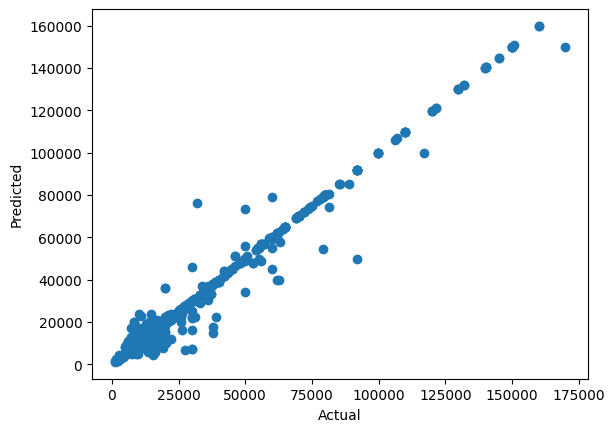

In [ ]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

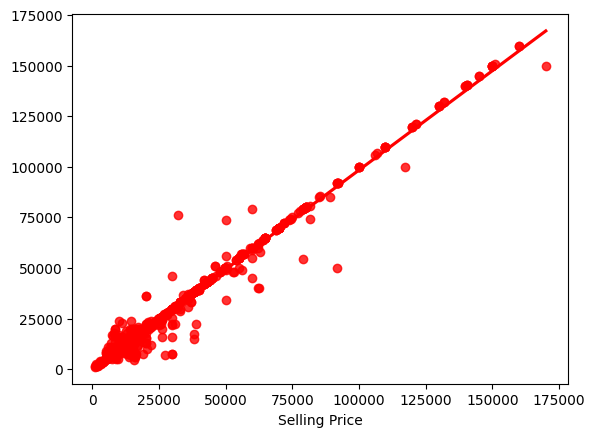

In [ ]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red'); 

### The final model is able to make predicatoins with model accuracy of 98.03 and only 6.73 percentage of errors which is industry grade 